**Import Libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

**Load Dataset**

In [ ]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Check Dataset**

In [ ]:
print(len(X_train))

25000


In [ ]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [ ]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


**Convert Back to Text**

In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value:key for (key,value) in word_index.items()
}

decoded_review = " ".join(

    reverse_word_index.get(i-3,"?")

    for i in X_train[0]

)

print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

**Padding**

In [ ]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

**Build RNN**

In [ ]:
model = Sequential()

**Embedding Layer**

In [ ]:
model.add(

    Embedding(

        input_dim=vocab_size,

        output_dim=128,

        input_length=max_length

    )

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**RNN Layer**

In [ ]:
model.add(

    SimpleRNN(

        64,

        activation="tanh"

    )

)

**Output Layer**

In [ ]:
model.add(

    Dense(

        1,

        activation="sigmoid"

    )

)

**Compile Model**

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

**Model Summary**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train**

In [ ]:
history = model.fit(

    X_train,

    y_train,

    epochs=5,

    batch_size=64,

    validation_split=0.2

)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.6709 - loss: 0.5857 - val_accuracy: 0.8086 - val_loss: 0.4368
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.8518 - loss: 0.3463 - val_accuracy: 0.6482 - val_loss: 0.6778
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.9148 - loss: 0.2157 - val_accuracy: 0.7674 - val_loss: 0.5787
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 0.7674 - val_loss: 0.7185
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.9969 - loss: 0.0151 - val_accuracy: 0.7642 - val_loss: 0.8300


**Evaluate**

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7616 - loss: 0.8367
Accuracy : 0.7615600228309631


**Plot Accuracy**

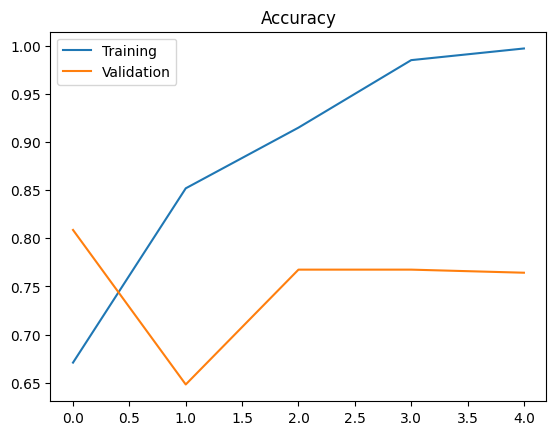

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Training","Validation"])

plt.title("Accuracy")

plt.show()

**Plot Loss**

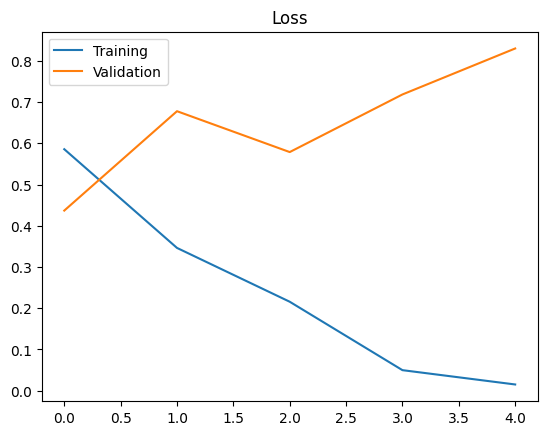

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.title("Loss")

plt.show()

**Predict New Review**

In [ ]:
sample_review = "This movie was fantastic and I loved it."

In [ ]:
# Convert it to numbers.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts([sample_review])

sequence = tokenizer.texts_to_sequences([sample_review])

sequence = pad_sequences(
    sequence,
    maxlen=max_length
)

In [ ]:
# Prediction

In [ ]:
prediction = model.predict(sequence)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
Negative Review
